# Brainwave Entrainment and Cognitive Performance  
### Experimental Data Analysis

## Overview

This project analyzes behavioral data from an experiment investigating the effects of **Brainwave Entrainment (BWE)** on cognitive performance.

Participants completed two types of tasks:

- **Continuous Performance Test (CPT)** — measures attention and response control  
- **Alternative Uses Task (AUT)** — measures creative output  

Each participant performed the tasks **before and after** exposure to audio-visual stimulation.

---

## Objective

The goal of this analysis is to determine whether BWE leads to measurable changes in:

- Creative performance (AUT)
- Reaction time (RT)
- Attention-related accuracy (CPT)

Additionally, the study compares two experimental groups:
- Group 1: one stimulation condition
- Group 2: alternative stimulation condition

---

## Data Characteristics

- 10 participants (9 with complete data)
- Within-subject design (pre vs post)

---

## Methodology

The analysis pipeline consists of:

1. **Metric extraction**  
   - CPT: hit rate, false alarm rate  
   - RT: average response time for target stimuli  
   - AUT: total number of responses  

2. **Dataset construction**  
   - Aggregates participant-level metrics  
   - Computes pre/post differences  

3. **Statistical analysis**  
   - Wilcoxon signed-rank test (within-subject)  
   - Mann–Whitney U test (between groups)  
   - Outlier robustness check  

---

## Key Findings

- No statistically significant improvement in creative performance after BWE exposure  
- No reliable difference between stimulation groups  
- Results are highly sensitive to individual variability and outliers  

---

## Interpretation

The findings suggest that:

- BWE does not produce a consistent group-level effect on creativity  
- Observed changes are likely **participant-specific rather than systematic**  
- The dataset is **highly variable and underpowered**, limiting general conclusions  

---

## Limitations

- Small sample size (n = 9)  
- CPT task lacks sensitivity (ceiling effects in hit rate)  
- Data collected in uncontrolled conditions  
- Presence of extreme outliers affecting results  


In [190]:
# ============================================
# Imports
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import zipfile

from scipy.stats import mannwhitneyu, wilcoxon
from google.colab import files

In [201]:
# ============================================
# Data upload and environment setup (ONLY if using Colab!)
# ============================================
'''
files.upload()

with zipfile.ZipFile("BWE_Cognitive_experiment.zip", 'r') as zip_ref:
    zip_ref.extractall("BWE_Cognitive_experiment")

os.chdir("BWE_Cognitive_experiment")
'''

'\nfiles.upload()\n\nwith zipfile.ZipFile("BWE_Cognitive_experiment.zip", \'r\') as zip_ref:\n    zip_ref.extractall("BWE_Cognitive_experiment")\n\nos.chdir("BWE_Cognitive_experiment")\n'

In [204]:
# ============================================
# Project setup (GitHub compatible! Comment out if using colab)
# ============================================

print("Current working directory:", os.getcwd())

data_folder = "data"

print(os.listdir("data"))

Current working directory: /content/project/project/BWE_Cognitive_experiment/BWE_Cognitive_experiment/BWE_Cognitive_experiment/BWE_Cognitive_experiment
['exp6_experimentet1_2024-03-15_12h09.08.041 OK.xlsx', 'exp6_experimentet2_2024-03-15_12h52.32.179 OK.xlsx', 'exp10_experimentet1_2024-03-17_17h17.50.447 OK.xlsx', 'exp9_experimentet1_2024-03-18_16h25.40.990 OK.xlsx', 'exp5_experimentet1_2024-03-14_14h00.58.339 OK.xlsx', 'exp3_experimentet2_2024-03-12_20h28.31.624 OK.xlsx', 'exp10_experimentet2_2024-03-17_17h57.33.767 OK.xlsx', 'ExperimentetData.xlsb.xlsx', 'exp9_experimentet2_2024-03-18_17h07.48.017.csv', 'exp8_experimentet1_2024-03-15_19h24.32.205 OK.xlsx', 'exp5_experimentet2_2024-03-14_14h38.42.306 OK.xlsx', 'exp2_experimentet1_2024-03-12_14h24.18.127 OK.xlsx', 'exp4_experimentet1_2024-03-14_11h38.14.957 OK.xlsx', 'exp4_experimentet2_2024-03-14_12h17.09.160 OK.xlsx', 'exp2_experimentet2_2024-03-12_15h09.44.100 OK.xlsx', 'exp7_experimentet1_2024-03-15_14h53.35.397 OK.xlsx', 'exp3_exp

In [205]:
# ============================================
# Organize files by participant and condition
# ============================================

files = os.listdir(data_folder)

participant_files = {}

for f in files:
    match = re.search(r"(exp\d+)_experimentet(\d)", f)

    if match:
        participant = match.group(1)
        condition = match.group(2)  # 1 = pre, 2 = post

        if participant not in participant_files:
            participant_files[participant] = {}

        participant_files[participant][condition] = os.path.join(data_folder, f)

participant_files

{'exp6': {'1': 'data/exp6_experimentet1_2024-03-15_12h09.08.041 OK.xlsx',
  '2': 'data/exp6_experimentet2_2024-03-15_12h52.32.179 OK.xlsx'},
 'exp10': {'1': 'data/exp10_experimentet1_2024-03-17_17h17.50.447 OK.xlsx',
  '2': 'data/exp10_experimentet2_2024-03-17_17h57.33.767 OK.xlsx'},
 'exp9': {'1': 'data/exp9_experimentet1_2024-03-18_16h25.40.990 OK.xlsx',
  '2': 'data/exp9_experimentet2_2024-03-18_17h07.48.017.csv'},
 'exp5': {'1': 'data/exp5_experimentet1_2024-03-14_14h00.58.339 OK.xlsx',
  '2': 'data/exp5_experimentet2_2024-03-14_14h38.42.306 OK.xlsx'},
 'exp3': {'2': 'data/exp3_experimentet2_2024-03-12_20h28.31.624 OK.xlsx',
  '1': 'data/exp3_experimentet1_2024-03-12_19h40.28.404 OK.xlsx'},
 'exp8': {'1': 'data/exp8_experimentet1_2024-03-15_19h24.32.205 OK.xlsx',
  '2': 'data/exp8_experimentet2_2024-03-15_20h10.35.074 OK.xlsx'},
 'exp2': {'1': 'data/exp2_experimentet1_2024-03-12_14h24.18.127 OK.xlsx',
  '2': 'data/exp2_experimentet2_2024-03-12_15h09.44.100 OK.xlsx'},
 'exp4': {'1':

In [194]:
# ============================================
# Data loading and metric extraction functions
# ============================================

def load_file(path):
    if path.endswith(".csv"):
        return pd.read_csv(path, sep=";", engine="python")
    else:
        return pd.read_excel(path)


def extract_metrics(df):

    # --- CPT (continuous performance test) ---
      # Extract trial-level data for attention task.
      # Rows with Presented_Number correspond to stimulus-response trials.
      # This subset is used to compute behavioral performance metrics.
    cpt = df[df["Presented_Number"].notna()].copy()

    for col in ["Presented_Number", "Correct", "False_Alarm", "Miss"]:
        if col in cpt.columns:
            cpt[col] = pd.to_numeric(cpt[col], errors="coerce")

    # --- RT (reaction time) ---
      # Compute average response time for target stimuli (number = 4).
      # Data may be stored in different columns depending on file format,
      # so a fallback strategy is used to ensure robust extraction.
    rt_values = pd.Series(dtype=float)

    if "omFyra.rt" in cpt.columns:
        cpt["omFyra.rt"] = (
            cpt["omFyra.rt"]
            .astype(str)
            .str.replace(",", ".", regex=False)
        )
        cpt["omFyra.rt"] = pd.to_numeric(cpt["omFyra.rt"], errors="coerce")
        rt_values = cpt.loc[cpt["Presented_Number"] == 4, "omFyra.rt"].dropna()

    if len(rt_values) == 0 and "Response_Time" in cpt.columns:
        cpt["Response_Time"] = (
            cpt["Response_Time"]
            .astype(str)
            .str.replace(",", ".", regex=False)
        )
        cpt["Response_Time"] = pd.to_numeric(cpt["Response_Time"], errors="coerce")
        rt_values = cpt.loc[cpt["Presented_Number"] == 4, "Response_Time"].dropna()

    rt_mean = rt_values.mean() if len(rt_values) > 0 else np.nan

    # --- Performance metrics ---
      # Compute task accuracy:
      # - Hit rate: correct responses to target stimuli (4)
      # - False alarm rate: incorrect responses to non-target stimuli
      # These metrics reflect attention and response control.
    targets = cpt["Presented_Number"] == 4
    non_targets = cpt["Presented_Number"] != 4

    hit_rate = cpt.loc[targets, "Correct"].mean() if targets.sum() > 0 else np.nan
    fa_rate = cpt.loc[non_targets, "False_Alarm"].mean() if non_targets.sum() > 0 else np.nan

    # --- AUT (alternative uses task) ---
      # Measure creative output by counting the number of unique responses.
      # Participants list alternative uses for an object; responses are
      # comma-separated and aggregated across all entries.
    def count_responses(series):
        total = 0
        for text in series:
            responses = [r.strip() for r in str(text).split(",") if r.strip()]
            total += len(responses)
        return total

    aut_pre = count_responses(df["textbox.text"].dropna()) if "textbox.text" in df.columns else np.nan
    aut_post = count_responses(df["textbox_4.text"].dropna()) if "textbox_4.text" in df.columns else np.nan

    return {
        "hit_rate": hit_rate,
        "fa_rate": fa_rate,
        "rt": rt_mean,
        "aut_pre": aut_pre,
        "aut_post": aut_post
    }

In [195]:
# ============================================
# Build participant-level dataset
# ============================================

results = []
excluded = []

for participant, conds in participant_files.items():

    if "1" in conds and "2" in conds:

        df_pre = load_file(conds["1"])
        df_post = load_file(conds["2"])

        pre = extract_metrics(df_pre)
        post = extract_metrics(df_post)

        results.append({
            "participant": participant,

            "hit_pre": pre["hit_rate"],
            "hit_post": post["hit_rate"],

            "fa_pre": pre["fa_rate"],
            "fa_post": post["fa_rate"],

            "rt_pre": pre["rt"],
            "rt_post": post["rt"],

            "aut_pre": pre["aut_pre"],
            "aut_post": post["aut_post"],

            "aut_change": post["aut_post"] - pre["aut_pre"],
            "rt_change": post["rt"] - pre["rt"]
        })

    else:
        excluded.append(participant)

results_df = pd.DataFrame(results)

print("Excluded participants:", excluded)
results_df

Excluded participants: ['exp1']


,participant,hit_pre,hit_post,fa_pre,fa_post,rt_pre,rt_post,aut_pre,aut_post,aut_change,rt_change
0,exp6,1.0,1.0,0.004219,0.008475,0.361357,0.410754,10,6,-4,0.049397
1,exp10,1.0,1.0,0.008368,0.004202,0.395014,0.399324,13,14,1,0.004310
2,exp9,1.0,1.0,0.000000,0.008368,0.446746,0.467898,12,8,-4,0.021152
3,exp5,1.0,1.0,0.008475,0.004219,0.388845,0.382999,2,1,-1,-0.005846
4,exp3,1.0,1.0,0.008439,0.004167,0.421498,0.439591,2,19,17,0.018093
5,exp8,NaN,1.0,0.000000,0.004167,NaN,0.351478,5,6,1,NaN
6,exp2,1.0,1.0,0.000000,0.004167,0.442572,0.391882,8,5,-3,-0.050689
7,exp4,1.0,1.0,0.008333,0.021008,0.444317,0.428662,12,8,-4,-0.015654
8,exp7,1.0,1.0,0.000000,0.004184,0.465947,0.464879,3,7,4,-0.001068


In [196]:
# ============================================
# Data quality check
# ============================================

print("Participants included:", len(results_df))
print(results_df["participant"].tolist())

print("\nMissing values:")
print(results_df.isna().sum())

print("\nSummary statistics:")
print(results_df.describe())

Participants included: 9
['exp6', 'exp10', 'exp9', 'exp5', 'exp3', 'exp8', 'exp2', 'exp4', 'exp7']

Missing values:
participant    0
hit_pre        1
hit_post       0
fa_pre         0
fa_post        0
rt_pre         1
rt_post        0
aut_pre        0
aut_post       0
aut_change     0
rt_change      1
dtype: int64

Summary statistics:
       hit_pre  hit_post    fa_pre   fa_post    rt_pre   rt_post    aut_pre  \
count      8.0       9.0  9.000000  9.000000  8.000000  9.000000   9.000000   
mean       1.0       1.0  0.004204  0.006995  0.420787  0.415274   7.444444   
std        0.0       0.0  0.004202  0.005566  0.035774  0.038624   4.530759   
min        1.0       1.0  0.000000  0.004167  0.361357  0.351478   2.000000   
25%        1.0       1.0  0.000000  0.004167  0.393471  0.391882   3.000000   
50%        1.0       1.0  0.004219  0.004202  0.432035  0.410754   8.000000   
75%        1.0       1.0  0.008368  0.008368  0.444924  0.439591  12.000000   
max        1.0       1.0  0.008

In [199]:
# ============================================
# Statistical analysis
# ============================================

# Remove outlier
filtered = results_df[results_df["aut_change"] < 10]

valid = filtered.dropna(subset=["aut_pre", "aut_post"])

if len(valid) > 1:
    stat, p = wilcoxon(valid["aut_pre"], valid["aut_post"])
    print("Wilcoxon p-value (AUT, no outlier):", p)
    print("Mean AUT change:", valid["aut_change"].mean())

# Group comparison
group_map = {
    "exp1": 1, "exp2": 2, "exp3": 1, "exp4": 2,
    "exp5": 1, "exp6": 2, "exp7": 1, "exp8": 2,
    "exp9": 1, "exp10": 2
}

results_df["group"] = results_df["participant"].map(group_map)

g1 = results_df[results_df["group"] == 1]["aut_change"]
g2 = results_df[results_df["group"] == 2]["aut_change"]

stat, p = mannwhitneyu(g1, g2)

print("\nGroup difference p:", p)
print("Group 1 mean:", g1.mean())
print("Group 2 mean:", g2.mean())

Wilcoxon p-value (AUT, no outlier): 0.375
Mean AUT change: -1.25

Group difference p: 0.38116022651163173
Group 1 mean: 4.0
Group 2 mean: -1.8


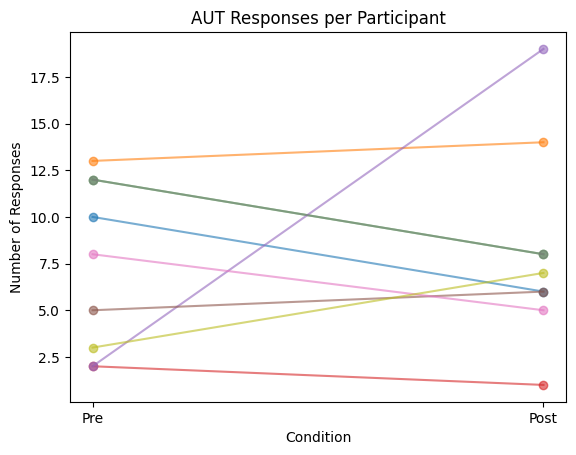

In [200]:
# ============================================
# Visualization: AUT Pre vs Post
# ============================================

plt.figure()

for i in range(len(results_df)):
    plt.plot(
        ["Pre", "Post"],
        [results_df.loc[i, "aut_pre"], results_df.loc[i, "aut_post"]],
        marker="o",
        alpha=0.6
    )

plt.title("AUT Responses per Participant")
plt.ylabel("Number of Responses")
plt.xlabel("Condition")
plt.show()